# IRF / DGP shape investigation

A scratchpad for *seeing* how the choice of VAR coefficients shapes the impulse response. The IRF shape is governed by the **eigenvalues of the companion matrix**:

* **Decaying** (monotone) — real, positive dominant eigenvalue.
* **Oscillatory** (cycles) — a complex conjugate pair with a *large* angle.
* **Hump** (rise then fall) — a complex pair with a *small* angle, so the first peak is delayed.

For each shape we show the two diagnostic views from `example_use.ipynb`:

* **1b** — a DGP realization, the structural shocks, and the true impulse responses.
* **1c** — the series $y_1$ built up as a sum of each period's decaying shock.

Persistence (spectral radius) and shape are independent; here we leave each DGP at its native persistence and just report it.

In [6]:
from functools import partial

import numpy as np
import matplotlib.pyplot as plt

from mcsim.dgp import (
    VARSpec, simulate_var, var_irf, var_ma_matrices, scale_to_persistence,
    spectral_radius, companion,
)


def describe(spec):
    """Print the companion eigenvalues, persistence, and a shape read-out."""
    eig = np.linalg.eigvals(companion(spec.A))
    dom = eig[np.argmax(np.abs(eig))]
    irf = var_irf(spec, 24)
    complex_pair = bool(np.any(np.abs(eig.imag) > 1e-8))
    print(f"spectral radius (persistence): {spectral_radius(spec.A):.3f}")
    print(f"dominant eigenvalue: {np.round(dom, 3)}  | complex pair: {complex_pair}")
    print(f"IRF var1<-shock1 peak at h={int(np.argmax(irf))}, "
          f"crosses zero: {bool(np.any(irf[1:] < -1e-6))}")


def show_dgp_and_irf(spec, title, T_show=200, H=20, seed=0):
    """Section 1b: a realization, the structural shocks, and the true IRFs."""
    rng = np.random.default_rng(seed)
    Y, shocks = simulate_var(spec, T_show, rng, return_shocks=True)
    irf = {(r, m): var_irf(spec, H, shock=m, response=r) for r in range(2) for m in range(2)}
    hh = np.arange(H + 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(Y[:, 0], lw=1, label="$y_1$")
    axes[0].plot(Y[:, 1], lw=1, alpha=0.8, label="$y_2$")
    axes[0].set_title(f"DGP realization (T={T_show})"); axes[0].set_xlabel("t"); axes[0].legend(fontsize=8)

    axes[1].plot(shocks[:, 0], lw=0.8, label=r"$\varepsilon_1$")
    axes[1].plot(shocks[:, 1], lw=0.8, alpha=0.7, label=r"$\varepsilon_2$")
    axes[1].set_title(r"Structural shocks $\varepsilon_t \sim N(0, I)$"); axes[1].set_xlabel("t"); axes[1].legend(fontsize=8)

    axes[2].plot(hh, irf[(0, 0)], marker="o", ms=3, label=r"$y_1 \leftarrow \varepsilon_1$")
    axes[2].plot(hh, irf[(1, 0)], marker="o", ms=3, label=r"$y_2 \leftarrow \varepsilon_1$")
    axes[2].plot(hh, irf[(0, 1)], marker="s", ms=3, ls="--", label=r"$y_1 \leftarrow \varepsilon_2$")
    axes[2].plot(hh, irf[(1, 1)], marker="s", ms=3, ls="--", label=r"$y_2 \leftarrow \varepsilon_2$")
    axes[2].axhline(0, color="k", lw=0.5)
    axes[2].set_title("True impulse responses"); axes[2].set_xlabel("horizon $h$"); axes[2].legend(fontsize=8)

    fig.suptitle(title, fontsize=13, fontweight="bold")
    fig.tight_layout(); plt.show()


def show_stacking(spec, title, T_bu=30, highlight=(0, 8, 16, 24), seed=1):
    """Section 1c: y_1 as the sum of each period's decaying shock (built from rest)."""
    rng = np.random.default_rng(seed)
    eps = rng.standard_normal((T_bu, 2))
    Psi = var_ma_matrices(spec.A, T_bu)
    Bm = spec.B
    contrib = np.zeros((T_bu, T_bu))
    for s in range(T_bu):
        for t in range(s, T_bu):
            contrib[s, t] = (Psi[t - s] @ Bm @ eps[s])[0]
    t_axis = np.arange(T_bu)

    fig, ax = plt.subplots(figsize=(12, 5))
    for s in range(T_bu):
        ax.plot(t_axis, contrib[s], color="0.8", lw=0.7, zorder=1)
    for s in highlight:
        ax.plot(t_axis, contrib[s], lw=1.8, marker="o", ms=3, zorder=3, label=f"shock at t={s}")
    ax.plot(t_axis, contrib.sum(axis=0), "k-", lw=2.6, zorder=4,
            label=r"observed $y_1$ = $\sum$ contributions")
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_title(title)
    ax.set_xlabel("t"); ax.set_ylabel("$y_1$")
    ax.legend(fontsize=8, ncol=2)
    fig.tight_layout(); plt.show()


B = np.array([[1.0, 0.0], [0.5, 1.0]])   # recursive impact matrix (shared unless noted)

## 1. Decaying (monotone)

Positive, diagonal-dominant $A_1$ with no higher lags. The companion eigenvalues are **real** — the response just decays geometrically toward zero, never overshooting.

spectral radius (persistence): 0.662
dominant eigenvalue: 0.662  | complex pair: False
IRF var1<-shock1 peak at h=0, crosses zero: False


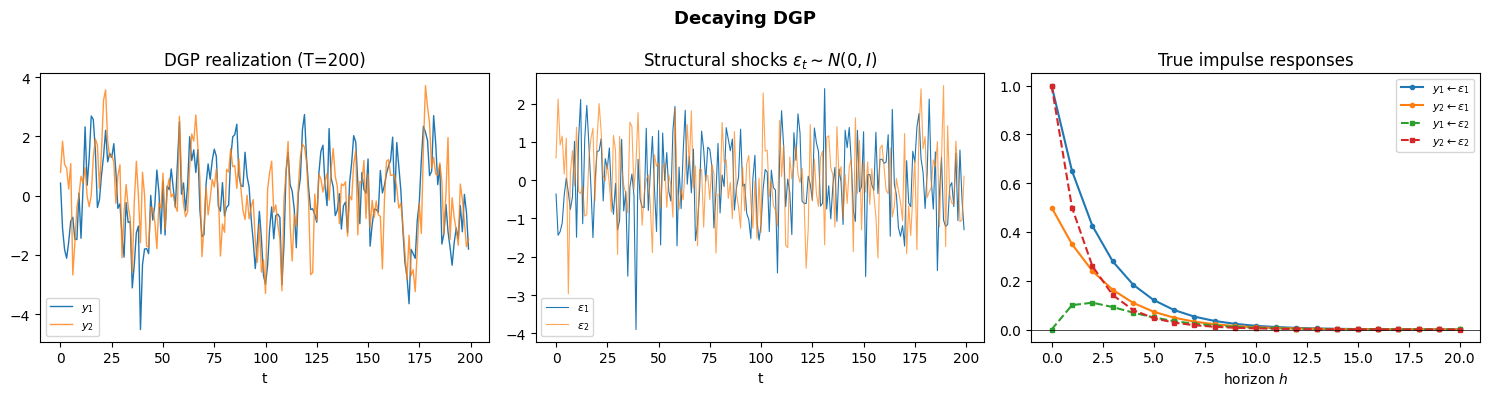

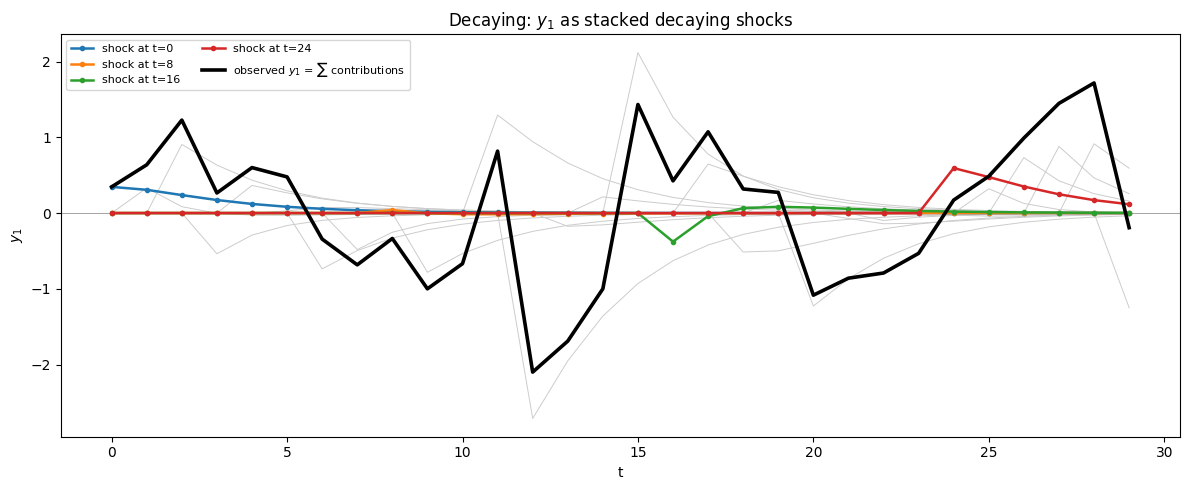

In [2]:
A_dec = np.array([[[0.6, 0.1], [0.1, 0.5]]])     # VAR(1), real eigenvalues
spec_dec = VARSpec(A=A_dec, B=B)
describe(spec_dec)
show_dgp_and_irf(spec_dec, "Decaying DGP")
show_stacking(spec_dec, "Decaying: $y_1$ as stacked decaying shocks")

## 2. Oscillatory (cycles)

A rotation structure $A_1 = \begin{pmatrix} a & b \\ -b & a \end{pmatrix}$ gives **complex** eigenvalues $a \pm bi$ with a large angle. The response rings down — overshooting zero and cycling back — with period $\approx 2\pi / \arctan(b/a)$.

spectral radius (persistence): 0.781
dominant eigenvalue: (0.5+0.6j)  | complex pair: True
IRF var1<-shock1 peak at h=0, crosses zero: True


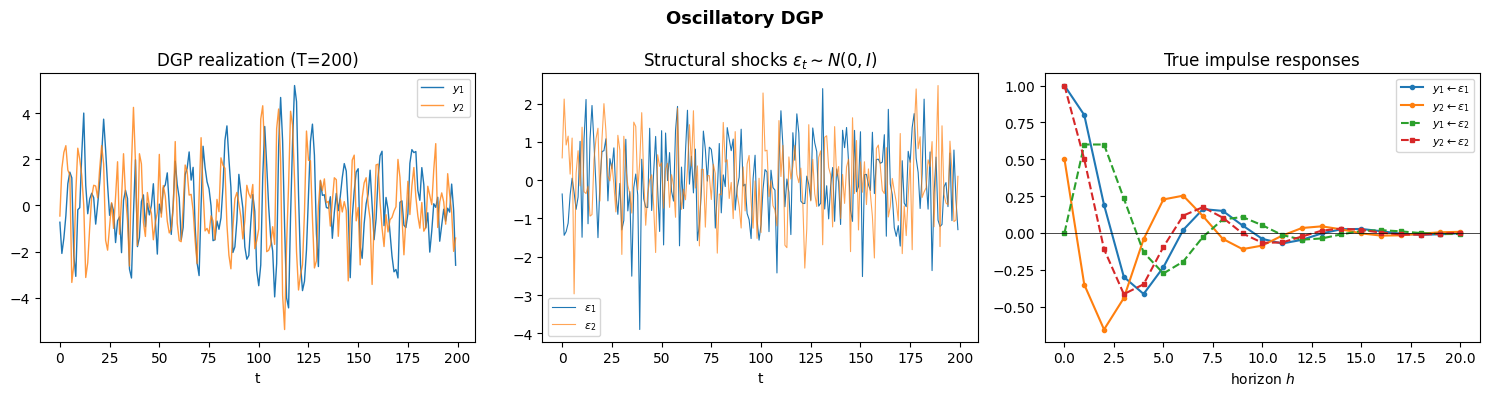

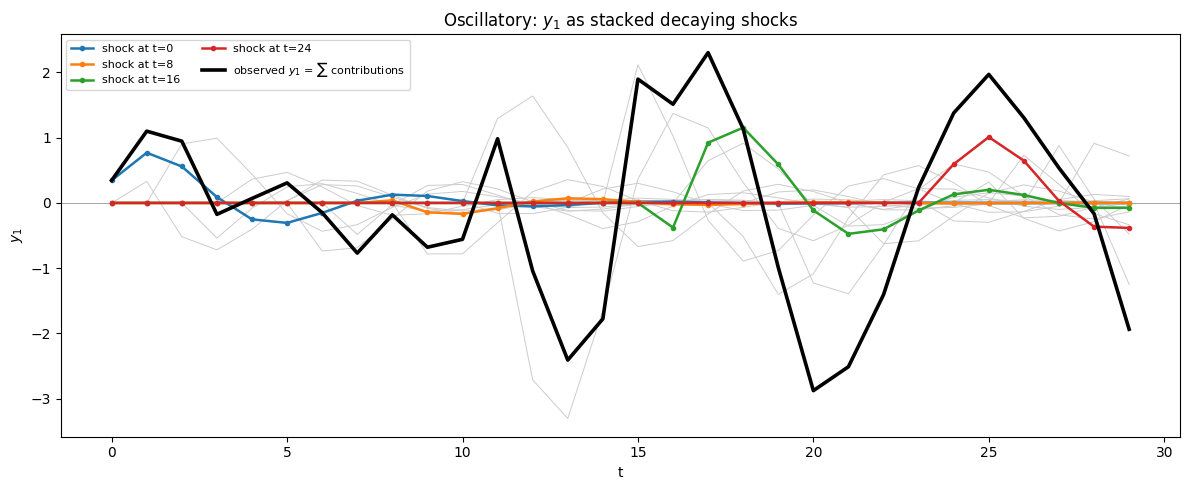

In [3]:
a, b = 0.5, 0.6
A_osc = np.array([[[a, b], [-b, a]]])           # VAR(1), complex eigenvalues a +/- bi
spec_osc = VARSpec(A=A_osc, B=B)
describe(spec_osc)
show_dgp_and_irf(spec_osc, "Oscillatory DGP")
show_stacking(spec_osc, "Oscillatory: $y_1$ as stacked decaying shocks")

## 3. Hump (rise then fall)

AR(2)-like own dynamics with $\phi_1 > 1$ and $\phi_2 < 0$ produce a **complex** pair with a *small* angle: the response builds up before fading, giving a delayed peak. A smaller impact ($b_{11} = 0.4$) makes the build-up visible.

spectral radius (persistence): 0.665
dominant eigenvalue: (0.622+0.233j)  | complex pair: True
IRF var1<-shock1 peak at h=1, crosses zero: True


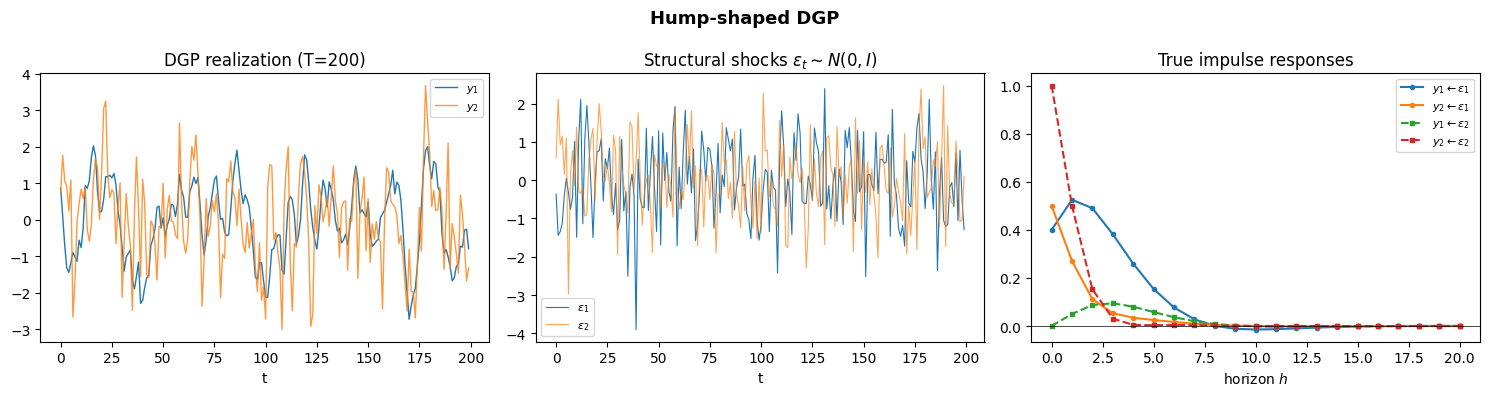

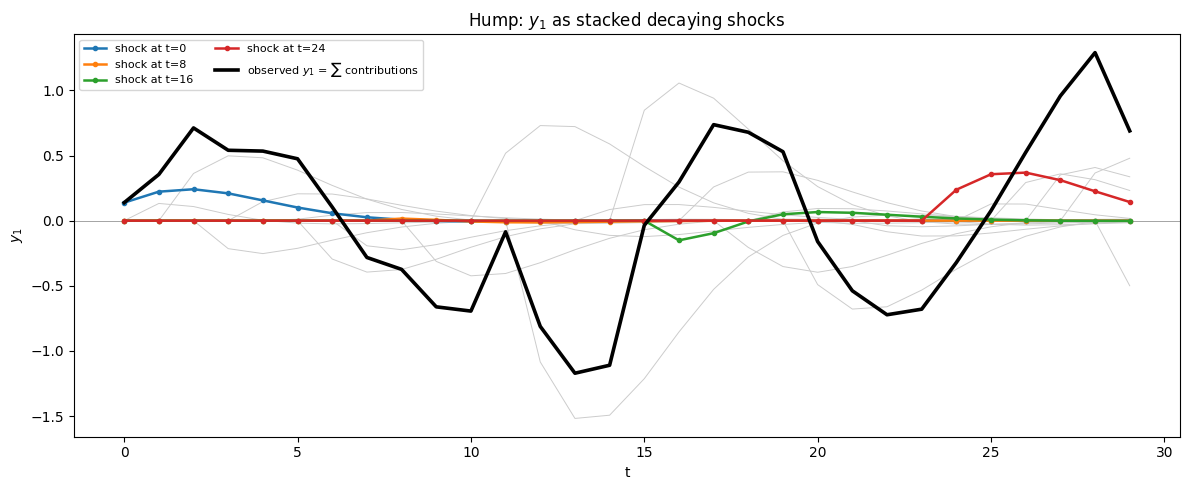

In [4]:
A_hump = np.array([
    [[1.25, 0.05], [0.05, 0.5]],                # A_1: phi1 = 1.25 (>1) -> momentum
    [[-0.45, 0.00], [0.00, -0.1]],              # A_2: phi2 = -0.45 (<0) -> eventual pull-back
])
B_hump = np.array([[0.4, 0.0], [0.5, 1.0]])     # smaller b_11 so the hump is visible
spec_hump = VARSpec(A=A_hump, B=B_hump)
describe(spec_hump)
show_dgp_and_irf(spec_hump, "Hump-shaped DGP")
show_stacking(spec_hump, "Hump: $y_1$ as stacked decaying shocks")

## 4. How often does random sampling hit each shape?

Draw 10,000 random stable bivariate VAR(4)s (the candidate randomization scheme: $N(0,1)$ coefficients scaled to a random persistence $\rho \sim U(0.5, 0.95)$, recursive $B$) and classify each IRF (var1 $\leftarrow$ shock1).

This checks whether "just randomize the coefficients" gives balanced coverage of the three shapes. The right panel plots each draw's **dominant eigenvalue** (modulus = persistence, angle = cycle frequency), showing that the three "shapes" are really regions of one continuous space — real axis → decaying, small angle → hump, large angle → oscillatory.

> The classifier is a heuristic (threshold `osc_tol`), and the proportions depend on the sampling scheme — both are knobs, not ground truth."

In [7]:
from collections import Counter


def classify_irf(v, osc_tol=0.33):
    """Classify a signed IRF (response of var1 to shock1).

    - large opposite-side excursion relative to the peak -> oscillatory
    - otherwise a delayed peak (peak away from impact)     -> hump
    - otherwise (peak at impact, negligible swing)         -> decaying
    """
    peak = np.max(np.abs(v))
    if peak < 1e-12:
        return "decaying"
    peak_h = int(np.argmax(np.abs(v)))
    s0 = np.sign(v[0]) or 1.0
    osc_ratio = max(0.0, float(np.max(-s0 * v))) / peak
    if osc_ratio >= osc_tol:
        return "oscillatory"
    return "hump" if peak_h >= 1 else "decaying"


def random_spec(rng):
    """A random stable bivariate VAR(4): N(0,1) coefficients scaled to a random
    persistence in the thesis range (0.5, 0.95), with recursive (lower-triangular)
    identification. (One candidate sampling scheme -- proportions depend on it.)"""
    A0 = rng.standard_normal((4, 2, 2))
    rho = rng.uniform(0.5, 0.95)
    A = scale_to_persistence(A0, rho)
    Bd = np.diag(rng.uniform(0.5, 1.5, 2))
    Bl = np.tril(rng.normal(0, 0.5, (2, 2)), -1)
    return VARSpec(A, Bd + Bl)


rng = np.random.default_rng(42)
N = 100_000
H_cls = 24

labels = np.empty(N, dtype=object)
dom_mod = np.empty(N)   # modulus of dominant eigenvalue (= persistence)
dom_ang = np.empty(N)   # |angle| of dominant eigenvalue (cycle frequency)
for i in range(N):
    spec = random_spec(rng)
    labels[i] = classify_irf(var_irf(spec, H_cls))
    eig = np.linalg.eigvals(companion(spec.A))
    d = eig[np.argmax(np.abs(eig))]
    dom_mod[i] = abs(d)
    dom_ang[i] = abs(np.angle(d))

counts = Counter(labels)
print(f"over {N:,} random stable bivariate VAR(4):")
for k in ("decaying", "hump", "oscillatory"):
    print(f"  {k:12s}: {counts[k]/N:6.1%}  ({counts[k]})")

over 100,000 random stable bivariate VAR(4):
  decaying    :  64.2%  (64175)
  hump        :   1.2%  (1221)
  oscillatory :  34.6%  (34604)


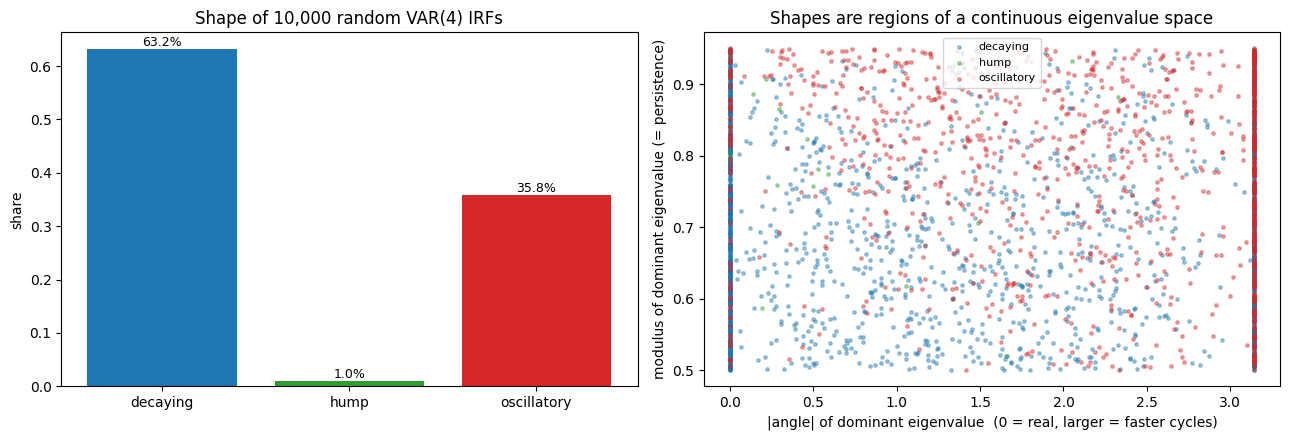

In [6]:
colors = {"decaying": "tab:blue", "hump": "tab:green", "oscillatory": "tab:red"}
order = ["decaying", "hump", "oscillatory"]

fig, (axb, axs) = plt.subplots(1, 2, figsize=(13, 4.5))

# (left) shares of each shape
axb.bar(order, [counts[k] / N for k in order], color=[colors[k] for k in order])
axb.set_ylabel("share"); axb.set_title(f"Shape of {N:,} random VAR(4) IRFs")
for i, k in enumerate(order):
    axb.text(i, counts[k] / N, f"{counts[k]/N:.1%}", ha="center", va="bottom", fontsize=9)

# (right) where each shape lives in eigenvalue space (dominant eigenvalue)
sub = rng.permutation(N)[:3000]
for k in order:
    m = labels[sub] == k
    axs.scatter(dom_ang[sub][m], dom_mod[sub][m], s=6, alpha=0.4, color=colors[k], label=k)
axs.set_xlabel("|angle| of dominant eigenvalue  (0 = real, larger = faster cycles)")
axs.set_ylabel("modulus of dominant eigenvalue (= persistence)")
axs.set_title("Shapes are regions of a continuous eigenvalue space")
axs.legend(fontsize=8)

fig.tight_layout(); plt.show()